In [1]:
def getLineAndCol(Npad):
    line, col = Npad, 1
    while(line > 8):
        line = line - 8
    while(Npad > 8):
        Npad = Npad - 8
        col = col + 1

    return line, col   

In [2]:
getLineAndCol(9)

(1, 2)

In [3]:
from math import sqrt, atan, asin, pi

Lx = 15 #cm
Ly = 19 #cm
H = 202.6 #cm

def getDeltaX(col_pad1, col_pad2):
    return (col_pad1 - col_pad2 - 1)*Lx+2*np.random.rand()*Lx

def getDeltaY(lin_pad1, lin_pad2):
    return (lin_pad1 - lin_pad2 -1)*Ly+2*np.random.rand()*Ly

def getZen(deltaX, deltaY):
    diag = sqrt(deltaX*deltaX + deltaY*deltaY)
    return (180 * atan(diag / H)/pi)

def getAzi(deltaX, deltaY):
    diag = sqrt(deltaX*deltaX + deltaY*deltaY)
    if(diag > 0):
        azi = asin(deltaY/diag)
        if (deltaX) <= 0.:
            azi = pi - azi
        if azi < 0 and (deltaX) > 0.:
            azi = 2*pi + azi
        return 180*azi/pi
    else:
        azi=np.random.rand()*360.
        return azi

In [4]:
import pandas as pd
import numpy as np

def calcAngles(Npad1, Npad2):
    lin_pad1, col_pad1 = getLineAndCol(Npad1)
    lin_pad2, col_pad2 = getLineAndCol(Npad2)

    deltaX = getDeltaX(col_pad1, col_pad2)
    deltaY = getDeltaY(lin_pad1, lin_pad2)

    zen = getZen(deltaX, deltaY)
    azi = getAzi(deltaX, deltaY)
    
    return azi, zen

In [5]:
calcAngles(2, 14)

(263.0332969024736, 17.372970888205145)

In [6]:
from math import sqrt, atan, asin, log10, pi
from matplotlib import pyplot as plt
import numpy as np 

Lx = 15 #cm
Ly = 19 #cm
H = 202.6 #cm

def espelhar(Npad):
    if(0<Npad<65):    
        line, col = Npad, 1
        while(line > 8):
            line = line - 8
        while(Npad > 8):
            Npad = Npad - 8
            col = col + 1
        col=8-col+1
        espelhada=(col-1)*8+line    
        return espelhada 
    else:
        return Npad


def getNpads(arquivo):
    nPads_RPC1,nPads_RPC2,nPads_RPC3=[],[],[]
    binario=open(arquivo, 'rb')   #lê o arqmyfile.binuivo binário
    array = np.fromfile(binario, dtype=np.uint8) #array para o qual os bytes do arquivo serão lidos
    tamanho=len(array) #tamanho do array lido
    indice=0 #indice usado para varrer o array
    while(indice<tamanho):     # converte de uint8_t para int comum e separa as pads de cada RPC em um array diferente
        pad1=int(array[indice+1])
        pad2=int(array[indice+2])
        nPads_RPC1.append(pad1)     
        nPads_RPC2.append(pad2)
        indice+=3
    return nPads_RPC1, nPads_RPC2


def getLineAndCol(Npad):
    line, col = Npad, 1
    while(line > 8):
        line = line - 8
    while(Npad > 8):
        Npad = Npad - 8
        col = col + 1

    return line, col   

def getDeltaX(col_pad1, col_pad2):
    return (col_pad1 - col_pad2-1)*Lx+2*np.random.rand()*Lx

def getDeltaY(lin_pad1, lin_pad2):
    return (lin_pad1 - lin_pad2-1)*Ly+2*np.random.rand()*Ly

def getZen(deltaX, deltaY):
    diag = sqrt(deltaX*deltaX + deltaY*deltaY)
    return (180 * atan(diag / H)/pi)

def getAzi(deltaX, deltaY):
    diag = sqrt(deltaX*deltaX + deltaY*deltaY)
    if(diag > 0):
        azi = asin(deltaY/diag)
        if (deltaX) <= 0.:
            azi = pi - azi
        if azi < 0 and (deltaX) > 0.:
            azi = 2*pi + azi
        return 180*azi/pi
    else:
        azi=random.rand()*360
        return azi

def calcAngles(Npad1, Npad2):
    lin_pad1, col_pad1 = getLineAndCol(Npad1)
    lin_pad2, col_pad2 = getLineAndCol(Npad2)

    deltaX = getDeltaX(col_pad1, col_pad2)
    deltaY = getDeltaY(lin_pad1, lin_pad2)

    zen = getZen(deltaX, deltaY)
    azi = getAzi(deltaX, deltaY)
    
    return azi, zen



In [7]:
nPads_RPC2, nPads_RPC1 = getNpads('EAFEXP_2024_09_28.bin')

In [8]:
# from ROOT import TH2D, TCanvas

azimutal, zenital = [], []
line_RPC1, col_RPC1 = [], []
line_RPC2, col_RPC2 = [], []
validpads1,validpads2=[],[]

# h2_top = TH2D("h2_top", "", 8, 0.5, 8.5, 8, 0.5, 8.5)

for i in range(len(nPads_RPC1)):
    nPad1=nPads_RPC1[i]
    nPad2=nPads_RPC2[i]
    if(0<nPad1<65 and 0<nPad2<65):
        validpads1.append(nPad1)
        validpads2.append(nPad2)
        line1, col1 = getLineAndCol(nPad1)
        line_RPC1.append(line1)
        col_RPC1.append(col1)
        line2, col2 = getLineAndCol(nPad2)
        line_RPC2.append(line2)
        col_RPC2.append(col2)
        azi,zen=calcAngles(nPad1,nPad2)    
        azimutal.append(azi)
        zenital.append(zen)
    # h2_top.Fill(col1, line1)
    
Npads_1, Npads_2 = np.array(validpads1), np.array(validpads2)
Azimute, Zenite = np.array(azimutal), np.array(zenital)

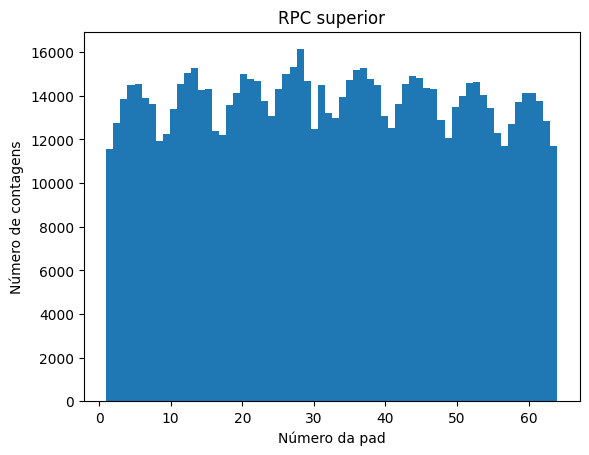

In [9]:
plt.hist(Npads_1, bins=64)
plt.ylabel("Número de contagens")
plt.xlabel("Número da pad")
plt.title("RPC superior")
plt.show()

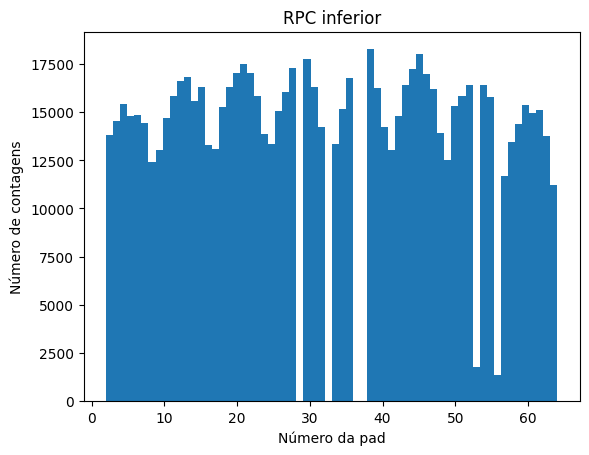

In [10]:
plt.hist(Npads_2, bins=64)
plt.ylabel("Número de contagens")
plt.xlabel("Número da pad")
plt.title("RPC inferior")
plt.show()

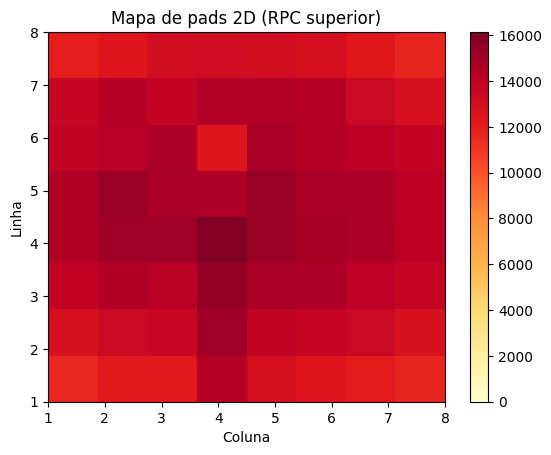

In [11]:
plt.hist2d(col_RPC1, line_RPC1, bins=[8,8], cmap="YlOrRd", vmin=0)
plt.colorbar()
plt.xlabel("Coluna")
plt.ylabel("Linha")
plt.title("Mapa de pads 2D (RPC superior)")
plt.show()

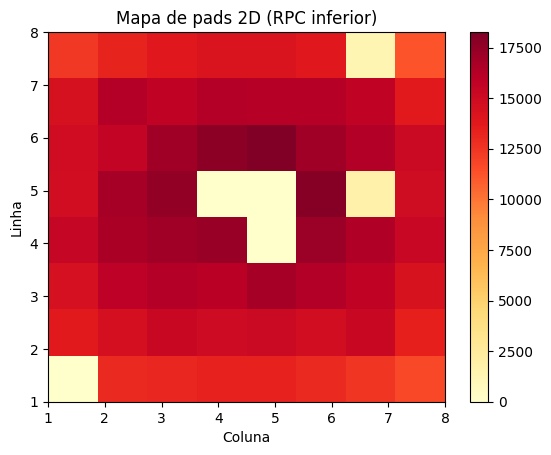

In [12]:
plt.hist2d(col_RPC2, line_RPC2, bins=[8,8], cmap="YlOrRd", vmin=0)
plt.colorbar()
plt.xlabel("Coluna")
plt.ylabel("Linha")
plt.title("Mapa de pads 2D (RPC inferior)")
plt.show()

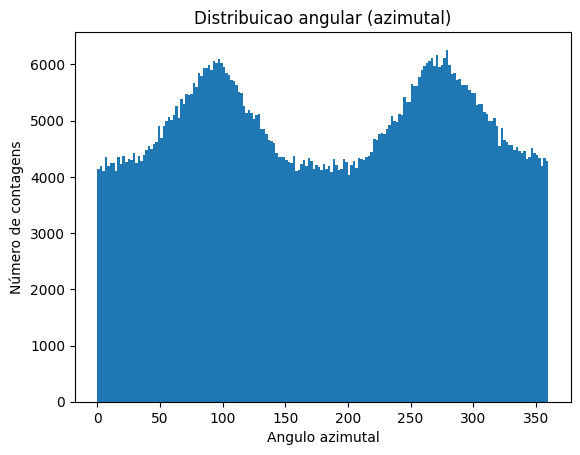

In [13]:
plt.hist(Azimute, bins=180, histtype='stepfilled')
plt.ylabel("Número de contagens")
plt.xlabel("Angulo azimutal")
plt.title("Distribuicao angular (azimutal)")
plt.show()

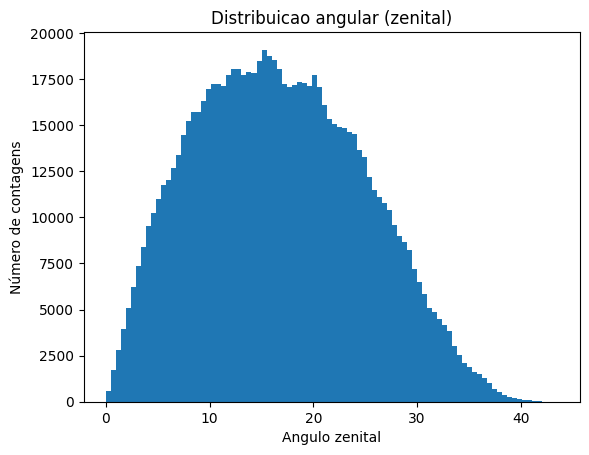

array([21.25521337, 22.62077853, 26.1178575 , ...,  7.77843921,
       17.89890187,  9.64311991])

In [14]:
plt.hist(Zenite, bins=90)
plt.ylabel("Número de contagens")
plt.xlabel("Angulo zenital")
plt.title("Distribuicao angular (zenital)")
plt.show()

Zenite

In [15]:
blacklist_RPC_1=[]
blacklist_RPC_2=[1,36,29,37,56,53]

In [16]:
from math import sqrt, atan, asin, log10, pi, cos, sin, tan
from matplotlib import pyplot as plt
import numpy as np
import random

Lx = 15 #cm
Ly = 19 #cm
borda = 0.5 #cm
H = 202.6 #cm

def getLineAndCol(Npad):
    line, col = Npad, 1
    while(line > 8):
        line = line - 8
    while(Npad > 8):
        Npad = Npad - 8
        col = col + 1
    return line, col  

def getNpad(x,y,borda):
    yposinpad=y-int(y/Ly)*Ly
    xposinpad=x-int(x/Lx)*Lx
    if (borda<xposinpad<(Lx-borda) and borda<yposinpad<(Ly-borda)):
        line=int(y/Ly)+1
        col=int(x/Lx)+1
        if (line<=8 and col<=8):
            return (col-1)*8+line
        else:
            return 0
    else:
        return 0

def sortPos():
    xsort=np.random.rand()*Lx*8
    ysort=np.random.rand()*Ly*8
    return xsort,ysort


def IsInsideRPCsup(x, y):
    testpad=getNpad(x,y,borda)
    if(testpad!=0):
        if testpad in blacklist_RPC_1:
            return False
        else:
            return True 
    else:
        return False


def IsInsideRPCinf(x, y):
    testpad=getNpad(x,y,borda)
    if(testpad!=0):
        if testpad in blacklist_RPC_2:
            return False
        else:
            return True  
    else:
        return False

def IsInsideRPC(x, y):
    return ((0.< x <= 8*Lx) and (0.<= y <= 8*Ly))
    
def calcPosInf(x_sup,y_sup,zen,azi,H):
        zen_tan=tan(zen)           
        slopex=cos(azi)*zen_tan
        slopey=sin(azi)*zen_tan
        x_inf=x_sup+slopex*H
        y_inf=y_sup+slopey*H
        return x_inf,y_inf
    
def sortcos2():
    while True:
        x=np.random.rand()*pi/2. #zenite indo de 0 até 90°
        y=np.random.rand()*2./(3.*np.sqrt(3.))
        fx=sin(x)*cos(x)**2.
        if(y<fx):
            return x
        
def sortuniform():
    while True:
        x=np.random.rand()*pi/2. #zenite indo de 0 até 90°
        y=np.random.rand()
        fx=sin(x)
        if(y<fx):
            return x

def ideal(Nevts, Npad1_list, Npad2_list):
    ievt=0
    while(ievt<Nevts):
        valid=0
        while(valid==0):
            x_sup,y_sup=sortPos()
            if (IsInsideRPCsup(x_sup,y_sup)):
                zen = sortuniform()
                #zen = sortcos2()
                azi = np.random.rand()*2*pi
                x_inf, y_inf = calcPosInf(x_sup,y_sup,zen,azi,H)
                if (IsInsideRPCinf(x_inf,y_inf)):
                    Npad_sup=getNpad(x_sup,y_sup,borda)
                    Npad_inf=getNpad(x_inf,y_inf,borda)   
                    if (Npad_sup!=0 and Npad_inf !=0):
                        valid=1
                        ievt+=1     
                        azi_list.append(azi)
                        zen_list.append(zen)
                        Npad1_list.append(Npad_sup)
                        Npad2_list.append(Npad_inf)             

In [17]:
Nevts = 100000000
nPads_RPC1, nPads_RPC2, zen_list, azi_list = [], [], [], []
ideal(Nevts, nPads_RPC1, nPads_RPC2)
Npads_1 = np.array(nPads_RPC1)
Npads_2 = np.array(nPads_RPC2)
Azimute_2, Zenite_2 = np.array(azi_list), np.array(zen_list)

In [18]:
# from ROOT import TH2D, TCanvas

azimutal, zenital = [], []
line_RPC1, col_RPC1 = [], []
line_RPC2, col_RPC2 = [], []
validpads1,validpads2=[],[]

# h2_top = TH2D("h2_top", "", 8, 0.5, 8.5, 8, 0.5, 8.5)

for i in range(len(nPads_RPC1)):
    nPad1=nPads_RPC1[i]
    nPad2=nPads_RPC2[i]
    if(0<nPad1<65 and 0<nPad2<65):
        validpads1.append(nPad1)
        validpads2.append(nPad2)
        line1, col1 = getLineAndCol(nPad1)
        line_RPC1.append(line1)
        col_RPC1.append(col1)
        line2, col2 = getLineAndCol(nPad2)
        line_RPC2.append(line2)
        col_RPC2.append(col2)
        azi,zen=calcAngles(nPad1,nPad2)    
        azimutal.append(azi)
        zenital.append(zen)
    # h2_top.Fill(col1, line1)
    
Npads_1, Npads_2 = np.array(validpads1), np.array(validpads2)
Azimute_2, Zenite_2 = np.array(azimutal), np.array(zenital)

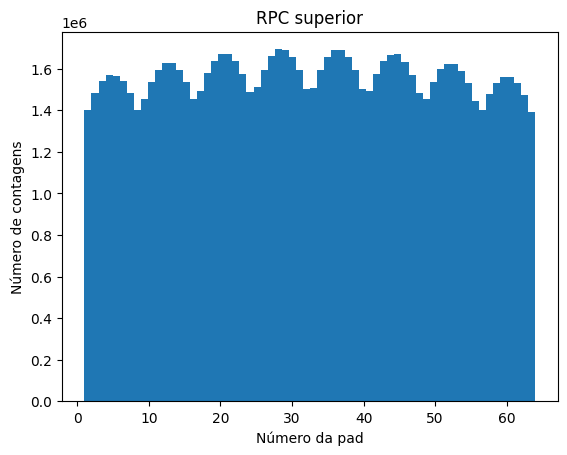

In [19]:
plt.hist(Npads_1, bins=64)
plt.ylabel("Número de contagens")
plt.xlabel("Número da pad")
plt.title("RPC superior")
plt.show()

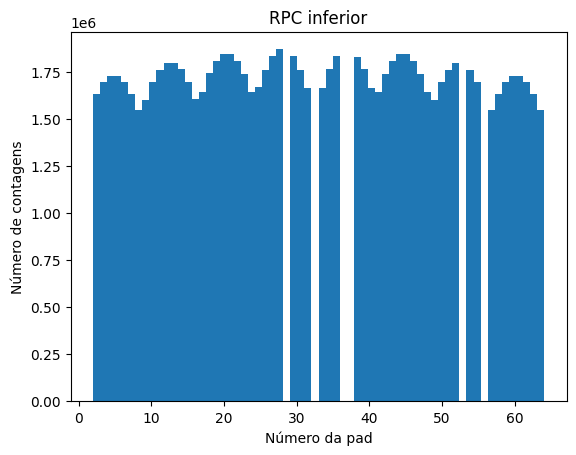

In [20]:
plt.hist(Npads_2, bins=64)
plt.ylabel("Número de contagens")
plt.xlabel("Número da pad")
plt.title("RPC inferior")
plt.show()

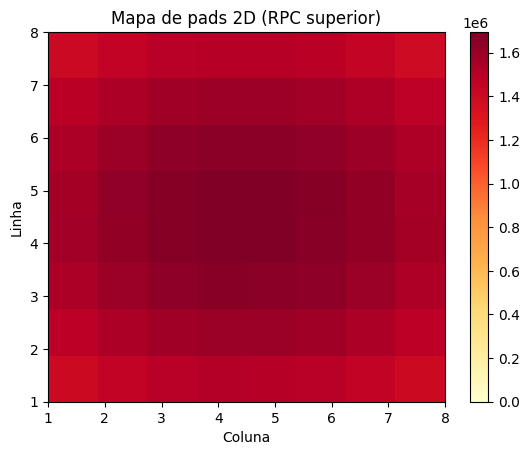

In [21]:
plt.hist2d(col_RPC1, line_RPC1, bins=[8,8], cmap="YlOrRd", vmin=0)
plt.colorbar()
plt.xlabel("Coluna")
plt.ylabel("Linha")
plt.title("Mapa de pads 2D (RPC superior)")
plt.show()

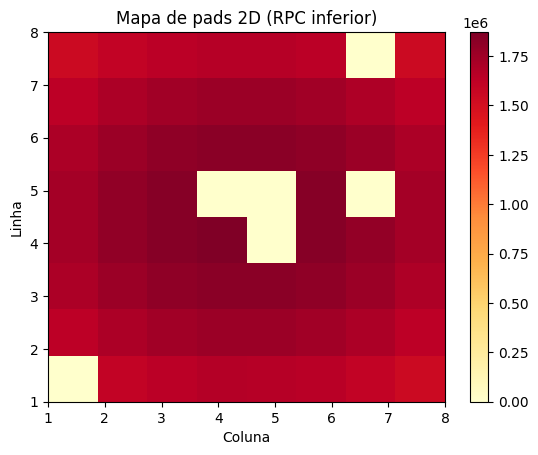

In [22]:
plt.hist2d(col_RPC2, line_RPC2, bins=[8,8], cmap="YlOrRd", vmin=0)
plt.colorbar()
plt.xlabel("Coluna")
plt.ylabel("Linha")
plt.title("Mapa de pads 2D (RPC inferior)")
plt.show()

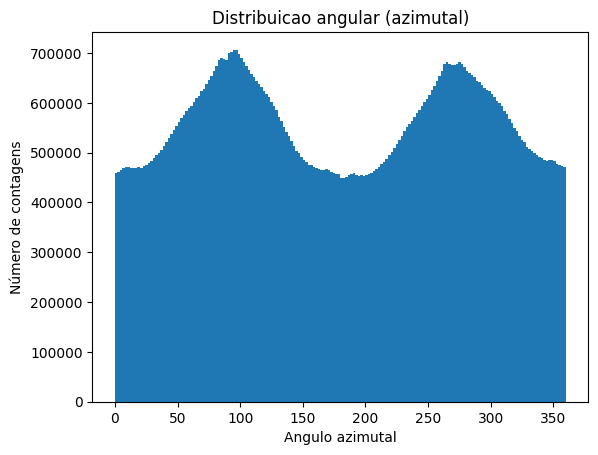

In [23]:
plt.hist(Azimute_2, bins=180, histtype='stepfilled')
plt.ylabel("Número de contagens")
plt.xlabel("Angulo azimutal")
plt.title("Distribuicao angular (azimutal)")
plt.show()

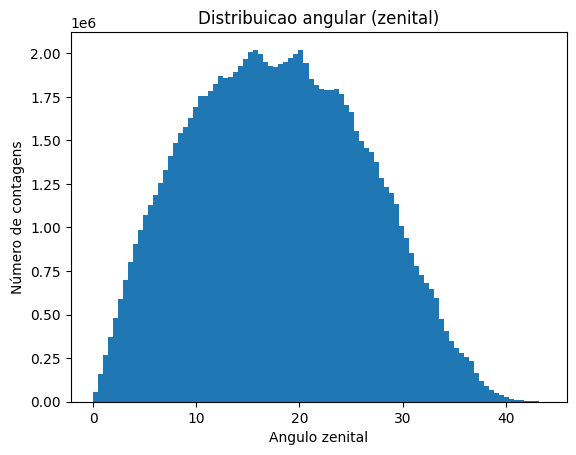

In [24]:
plt.hist(Zenite_2, bins=90)
plt.ylabel("Número de contagens")
plt.xlabel("Angulo zenital")
plt.title("Distribuicao angular (zenital)")
plt.show()

Welcome to JupyROOT 6.30/02


Info in <TCanvas::Print>: png file hist.png has been created
Info in <TCanvas::Print>: png file Razão.png has been created


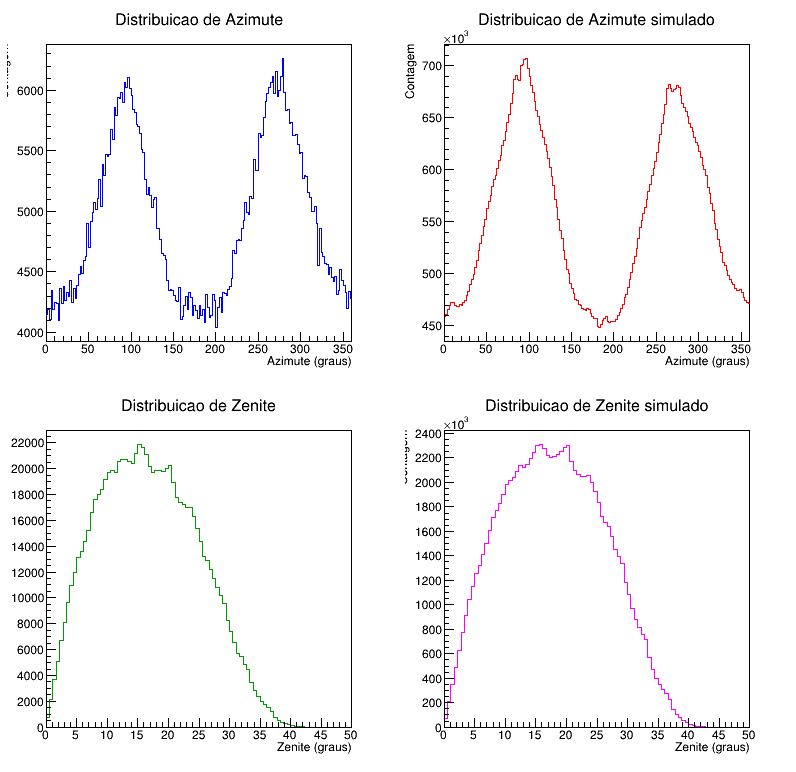

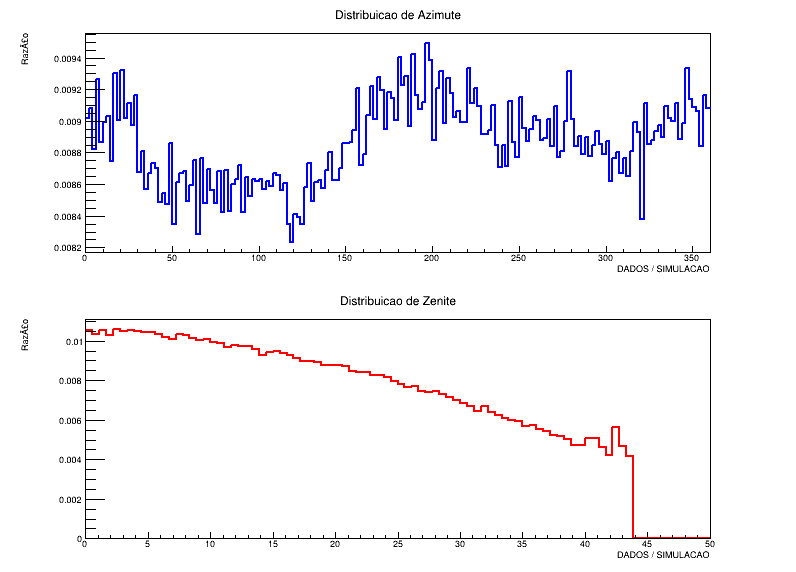

In [25]:
import ROOT

c1 = ROOT.TCanvas("c1", "Histogramas", 800, 800)
c2 = ROOT.TCanvas("c2", "Razao Dados/Simulacao", 800, 600)
c1.Divide(2, 2)
c2.Divide(1, 2)

hist1 = ROOT.TH1F("hist1", "Distribuicao de Azimute", 180, 0, 360)
hist2 = ROOT.TH1F("hist2", "Distribuicao de Azimute simulado", 180, 0, 360)
hist3 = ROOT.TH1F("hist3", "Distribuicao de Zenite", 90, 0, 50)
hist4 = ROOT.TH1F("hist4", "Distribuicao de Zenite simulado", 90, 0, 50)

Azimute = list(Azimute) # dados
Azimute_2 = list(Azimute_2) # simulado
Zenite = list(Zenite) # dados
Zenite_2 = list(Zenite_2) # simulado

def fill_histogram(hist, data):
    for value in data:
        hist.Fill(value)

fill_histogram(hist1, Azimute)
fill_histogram(hist2, Azimute_2)
fill_histogram(hist3, Zenite)
fill_histogram(hist4, Zenite_2)

hist1.SetLineColor(ROOT.kBlue)
hist2.SetLineColor(ROOT.kRed)
hist3.SetLineColor(ROOT.kGreen + 2)
hist4.SetLineColor(ROOT.kMagenta)

c1.cd(1)
hist1.SetStats(0)  
hist1.Draw("HIST")  
hist1.GetXaxis().SetTitle("Azimute (graus)")
hist1.GetYaxis().SetTitle("Contagem")

c1.cd(2)
hist2.SetStats(0)  
hist2.Draw("HIST")
hist2.GetXaxis().SetTitle("Azimute (graus)")
hist2.GetYaxis().SetTitle("Contagem")

c1.cd(3)
hist3.SetStats(0)  
hist3.Draw("HIST")
hist3.GetXaxis().SetTitle("Zenite (graus)")
hist3.GetYaxis().SetTitle("Contagem")

c1.cd(4)
hist4.SetStats(0)  
hist4.Draw("HIST")
hist4.GetXaxis().SetTitle("Zenite (graus)")
hist4.GetYaxis().SetTitle("Contagem")

c1.Draw()
c1.SaveAs("hist.png")


histo_razao1 = hist1.Clone("histo_razao")  
histo_razao1.Divide(hist2)

histo_razao2 = hist3.Clone("histo_razao")  
histo_razao2.Divide(hist4)

c2.cd(1)
histo_razao1.SetLineColor(ROOT.kBlue)
histo_razao1.SetLineWidth(2)
histo_razao1.GetXaxis().SetTitle("DADOS / SIMULACAO")
histo_razao1.GetYaxis().SetTitle("Razão")
histo_razao1.GetYaxis().SetTitleOffset(1.4)
histo_razao1.SetStats(0)  
histo_razao1.Draw("HIST")

c2.cd(2)
histo_razao2.SetLineColor(ROOT.kRed)
histo_razao2.SetLineWidth(2)
histo_razao2.GetXaxis().SetTitle("DADOS / SIMULACAO")
histo_razao2.GetYaxis().SetTitle("Razão")
histo_razao2.GetYaxis().SetTitleOffset(1.4)
histo_razao2.SetStats(0)  
histo_razao2.Draw("HIST")

c2.Draw()
c2.SaveAs("Razão.png")

Warning in <TROOT::Append>: Replacing existing TH1: hist1 (Potential memory leak).
Warning in <TROOT::Append>: Replacing existing TH1: hist2 (Potential memory leak).
Warning in <TROOT::Append>: Replacing existing TH1: hist3 (Potential memory leak).
Warning in <TROOT::Append>: Replacing existing TH1: hist4 (Potential memory leak).
Info in <TCanvas::Print>: png file hist_2.png has been created
Info in <TCanvas::Print>: png file Razão_2.png has been created


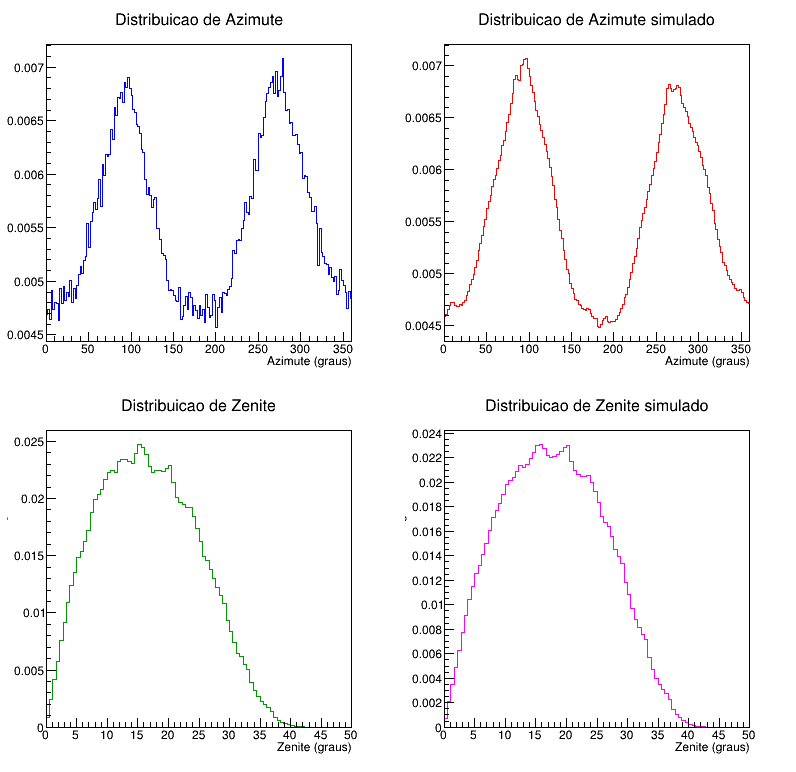

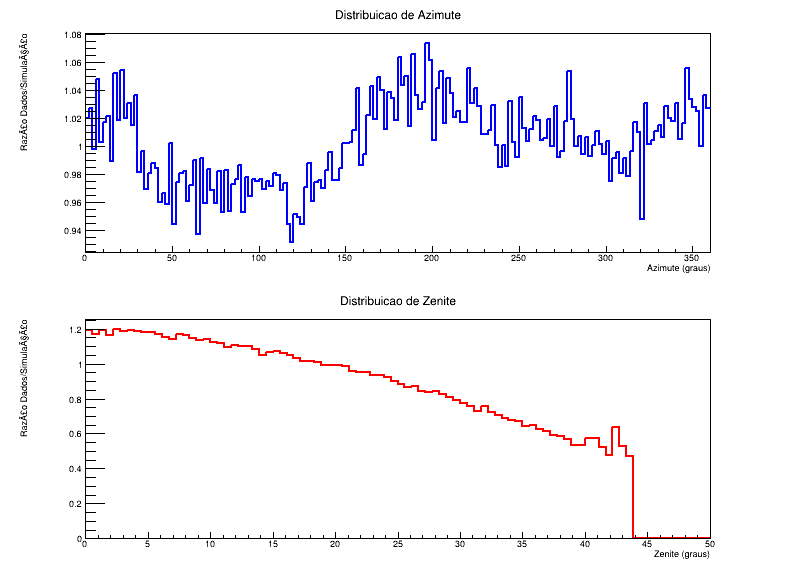

In [26]:
import ROOT

c3 = ROOT.TCanvas("c3", "Histogramas", 800, 800)
c4 = ROOT.TCanvas("c4", "Razao Dados/Simulacao", 800, 600)
c3.Divide(2, 2)
c4.Divide(1, 2)

hist1 = ROOT.TH1F("hist1", "Distribuicao de Azimute", 180, 0, 360)
hist2 = ROOT.TH1F("hist2", "Distribuicao de Azimute simulado", 180, 0, 360)
hist3 = ROOT.TH1F("hist3", "Distribuicao de Zenite", 90, 0, 50)
hist4 = ROOT.TH1F("hist4", "Distribuicao de Zenite simulado", 90, 0, 50)

Azimute = list(Azimute)  # dados
Azimute_2 = list(Azimute_2)  # simulado
Zenite = list(Zenite)  # dados
Zenite_2 = list(Zenite_2)  # simulado

def fill_histogram(hist, data):
    for value in data:
        hist.Fill(value)

fill_histogram(hist1, Azimute)
fill_histogram(hist2, Azimute_2)
fill_histogram(hist3, Zenite)
fill_histogram(hist4, Zenite_2)

hist1.Scale(1.0 / hist1.Integral())
hist2.Scale(1.0 / hist2.Integral())
hist3.Scale(1.0 / hist3.Integral())
hist4.Scale(1.0 / hist4.Integral())

hist1.SetLineColor(ROOT.kBlue)
hist2.SetLineColor(ROOT.kRed)
hist3.SetLineColor(ROOT.kGreen + 2)
hist4.SetLineColor(ROOT.kMagenta)

c3.cd(1)
hist1.SetStats(0)
hist1.Draw("HIST")
hist1.GetXaxis().SetTitle("Azimute (graus)")
hist1.GetYaxis().SetTitle("Contagem normalizada")

c3.cd(2)
hist2.SetStats(0)
hist2.Draw("HIST")
hist2.GetXaxis().SetTitle("Azimute (graus)")
hist2.GetYaxis().SetTitle("Contagem normalizada")

c3.cd(3)
hist3.SetStats(0)
hist3.Draw("HIST")
hist3.GetXaxis().SetTitle("Zenite (graus)")
hist3.GetYaxis().SetTitle("Contagem normalizada")

c3.cd(4)
hist4.SetStats(0)
hist4.Draw("HIST")
hist4.GetXaxis().SetTitle("Zenite (graus)")
hist4.GetYaxis().SetTitle("Contagem normalizada")

c3.Draw()
c3.SaveAs("hist_2.png")

histo_razao1 = hist1.Clone("histo_razao1")
histo_razao1.Divide(hist2)

histo_razao2 = hist3.Clone("histo_razao2")
histo_razao2.Divide(hist4)

c4.cd(1)
histo_razao1.SetLineColor(ROOT.kBlue)
histo_razao1.SetLineWidth(2)
histo_razao1.GetXaxis().SetTitle("Azimute (graus)")
histo_razao1.GetYaxis().SetTitle("Razão Dados/Simulação")
histo_razao1.GetYaxis().SetTitleOffset(1.4)
histo_razao1.SetStats(0)
histo_razao1.Draw("HIST")

c4.cd(2)
histo_razao2.SetLineColor(ROOT.kRed)
histo_razao2.SetLineWidth(2)
histo_razao2.GetXaxis().SetTitle("Zenite (graus)")
histo_razao2.GetYaxis().SetTitle("Razão Dados/Simulação")
histo_razao2.GetYaxis().SetTitleOffset(1.4)
histo_razao2.SetStats(0)
histo_razao2.Draw("HIST")

c4.Draw()
c4.SaveAs("Razão_2.png")

Warning in <TROOT::Append>: Replacing existing TH1: hist1 (Potential memory leak).
Warning in <TROOT::Append>: Replacing existing TH1: hist2 (Potential memory leak).
Warning in <TROOT::Append>: Replacing existing TH1: hist3 (Potential memory leak).
Warning in <TROOT::Append>: Replacing existing TH1: hist4 (Potential memory leak).
Info in <TCanvas::Print>: png file hist_3.png has been created


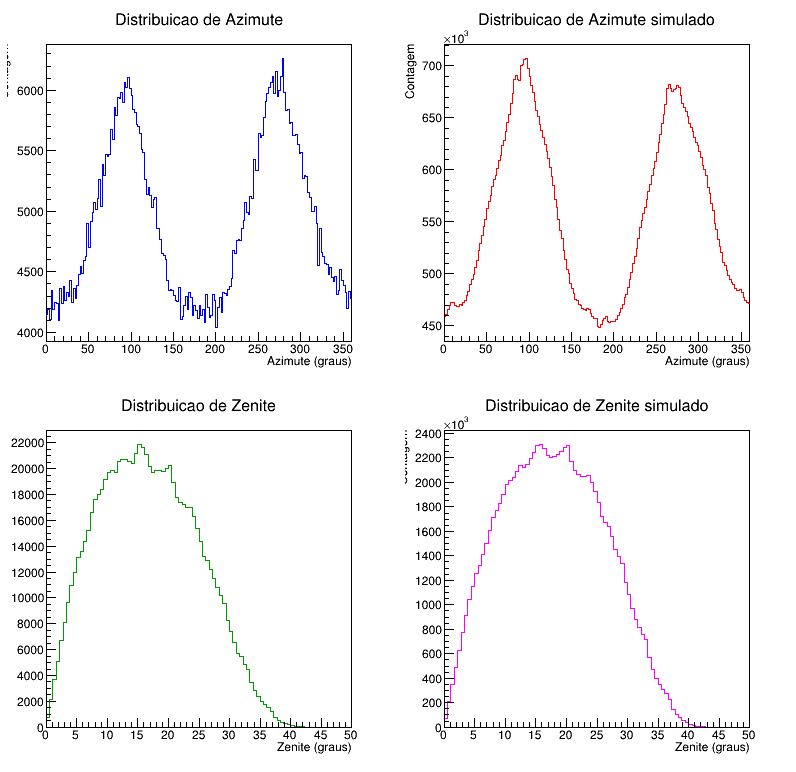

In [27]:
import ROOT

c5 = ROOT.TCanvas("c5", "Histogramas", 800, 800)
c6 = ROOT.TCanvas("c6", "Razao Dados/Simulacao", 800, 600)
c5.Divide(2, 2)
c6.Divide(1, 2)

hist1 = ROOT.TH1F("hist1", "Distribuicao de Azimute", 180, 0, 360)
hist2 = ROOT.TH1F("hist2", "Distribuicao de Azimute simulado", 180, 0, 360)
hist3 = ROOT.TH1F("hist3", "Distribuicao de Zenite", 90, 0, 50)
hist4 = ROOT.TH1F("hist4", "Distribuicao de Zenite simulado", 90, 0, 50)

Azimute = list(Azimute)  # dados
Azimute_2 = list(Azimute_2)  # simulado
Zenite = list(Zenite)  # dados
Zenite_2 = list(Zenite_2)  # simulado

def fill_histogram(hist, data):
    for value in data:
        hist.Fill(value)

fill_histogram(hist1, Azimute)
fill_histogram(hist2, Azimute_2)
fill_histogram(hist3, Zenite)
fill_histogram(hist4, Zenite_2)

hist1.SetLineColor(ROOT.kBlue)
hist2.SetLineColor(ROOT.kRed)
hist3.SetLineColor(ROOT.kGreen + 2)
hist4.SetLineColor(ROOT.kMagenta)

c5.cd(1)
hist1.SetStats(0)
hist1.Draw("HIST")
hist1.GetXaxis().SetTitle("Azimute (graus)")
hist1.GetYaxis().SetTitle("Contagem")

c5.cd(2)
hist2.SetStats(0)
hist2.Draw("HIST")
hist2.GetXaxis().SetTitle("Azimute (graus)")
hist2.GetYaxis().SetTitle("Contagem")

c5.cd(3)
hist3.SetStats(0)
hist3.Draw("HIST")
hist3.GetXaxis().SetTitle("Zenite (graus)")
hist3.GetYaxis().SetTitle("Contagem")

c5.cd(4)
hist4.SetStats(0)
hist4.Draw("HIST")
hist4.GetXaxis().SetTitle("Zenite (graus)")
hist4.GetYaxis().SetTitle("Contagem")

c5.Draw()
c5.SaveAs("hist_3.png")

Info in <TCanvas::Print>: png file Razão_3.png has been created


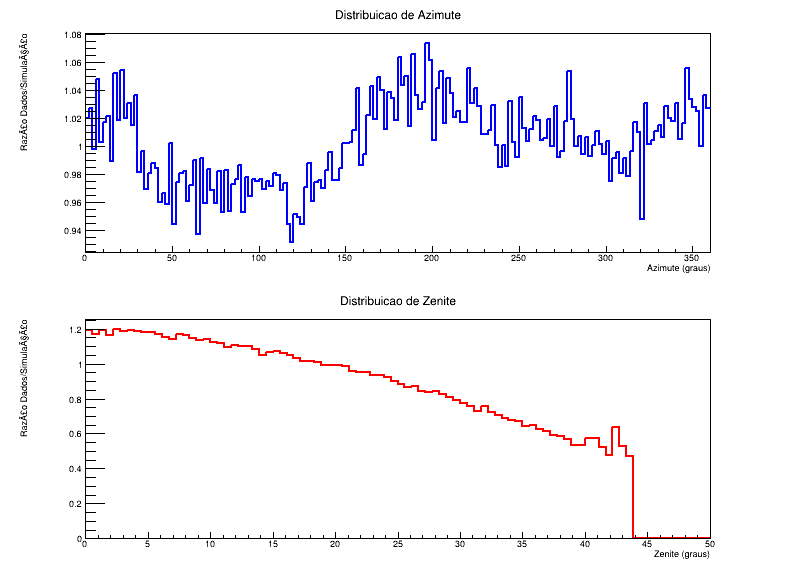

In [28]:
hist1.Scale(1.0 / hist1.Integral())
hist2.Scale(1.0 / hist2.Integral())
hist3.Scale(1.0 / hist3.Integral())
hist4.Scale(1.0 / hist4.Integral())

histo_razao1 = hist1.Clone("histo_razao1")
histo_razao1.Divide(hist2)

histo_razao2 = hist3.Clone("histo_razao2")
histo_razao2.Divide(hist4)

c6.cd(1)
histo_razao1.SetLineColor(ROOT.kBlue)
histo_razao1.SetLineWidth(2)
histo_razao1.GetXaxis().SetTitle("Azimute (graus)")
histo_razao1.GetYaxis().SetTitle("Razão Dados/Simulação")
histo_razao1.GetYaxis().SetTitleOffset(1.4)
histo_razao1.SetStats(0)
histo_razao1.Draw("HIST")

c6.cd(2)
histo_razao2.SetLineColor(ROOT.kRed)
histo_razao2.SetLineWidth(2)
histo_razao2.GetXaxis().SetTitle("Zenite (graus)")
histo_razao2.GetYaxis().SetTitle("Razão Dados/Simulação")
histo_razao2.GetYaxis().SetTitleOffset(1.4)
histo_razao2.SetStats(0)
histo_razao2.Draw("HIST")

c6.Draw()
c6.SaveAs("Razão_3.png")